In [107]:
import os
import tensorflow as tf
from tensorflow.keras import layers, callbacks
import matplotlib.pyplot as plt
import numpy as np

In [108]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 8
CHANNELS = 3
EPOCHS = 40
LEARNING_RATE = 1e-4

In [109]:
VALID_CLASSES = [
    'Black Scurf', 'Blackleg', 'Common Scab',
    'Dry Rot', 'Healthy Potatoes', 'Miscellaneous', 'Pink Rot'
]

os.makedirs("saved_model", exist_ok=True)

train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    class_names=VALID_CLASSES,
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    class_names=VALID_CLASSES,
)

class_names = train_ds.class_names
n_classes = len(class_names)

print(f"Classes ({n_classes}): {class_names}")

val_batches = len(val_test_ds) // 2

val_ds = val_test_ds.take(val_batches)
test_ds = val_test_ds.skip(val_batches)

print(f"Train batches : {len(train_ds)}")
print(f"Validation    : {len(val_ds)}")
print(f"Test          : {len(test_ds)}")

Found 451 files belonging to 7 classes.
Using 361 files for training.
Found 451 files belonging to 7 classes.
Using 90 files for validation.
Classes (7): ['Black Scurf', 'Blackleg', 'Common Scab', 'Dry Rot', 'Healthy Potatoes', 'Miscellaneous', 'Pink Rot']
Train batches : 46
Validation    : 6
Test          : 6


In [110]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
], name="augmentation")

base_model = tf.keras.applications.EfficientNetV2B0(
    input_shape=(*IMAGE_SIZE, CHANNELS),
    include_top=False,
    weights='imagenet',
    include_preprocessing=True
)
base_model.trainable = False

inputs  = tf.keras.Input(shape=(*IMAGE_SIZE, CHANNELS))
x = augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(n_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs, name="PotatoDisease_EfficientNetV2B0")
model.summary()

Model: "PotatoDisease_EfficientNetV2B0"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_17 (InputLayer)       [(None, 224, 224, 3)]     0         
                                                                 
 augmentation (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 efficientnetv2-b0 (Functio  (None, 7, 7, 1280)        5919312   
 nal)                                                            
                                                                 
 global_average_pooling2d_7  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_11 (Dense)            (None, 128)               163968    
                                                                 
 batch_normalization_4 (Bat  (None, 

In [111]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

cb1 = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint('../saved_models/phase1_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-7, verbose=1),
]

print("\n=== PHASE 1: Training head ===")
h1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=cb1, verbose=1)


=== PHASE 1: Training head ===
Epoch 1/40
46/46 [==============================] - ETA: 0s - loss: 2.2632 - accuracy: 0.2244
Epoch 1: val_accuracy improved from -inf to 0.43750, saving model to ../saved_models\phase1_model.h5


d:\Project\PCD\04 - Project Potato Disease Classsification System\.venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


46/46 [==============================] - 23s 315ms/step - loss: 2.2632 - accuracy: 0.2244 - val_loss: 1.7070 - val_accuracy: 0.4375 - lr: 1.0000e-04
Epoch 2/40
46/46 [==============================] - ETA: 0s - loss: 1.8161 - accuracy: 0.3380
Epoch 2: val_accuracy improved from 0.43750 to 0.56250, saving model to ../saved_models\phase1_model.h5
46/46 [==============================] - 10s 222ms/step - loss: 1.8161 - accuracy: 0.3380 - val_loss: 1.5072 - val_accuracy: 0.5625 - lr: 1.0000e-04
Epoch 3/40
46/46 [==============================] - ETA: 0s - loss: 1.5557 - accuracy: 0.4127
Epoch 3: val_accuracy did not improve from 0.56250
46/46 [==============================] - 8s 166ms/step - loss: 1.5557 - accuracy: 0.4127 - val_loss: 1.3674 - val_accuracy: 0.5625 - lr: 1.0000e-04
Epoch 4/40
46/46 [==============================] - ETA: 0s - loss: 1.3544 - accuracy: 0.4765
Epoch 4: val_accuracy improved from 0.56250 to 0.60417, saving model to ../saved_models\phase1_model.h5
46/46 [======

In [112]:
print("\n=== PHASE 2: Fine-tuning ===")
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(LEARNING_RATE / 10),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

cb2 = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, verbose=1),
    callbacks.ModelCheckpoint('../saved_models/final_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, min_lr=1e-8, verbose=1),
]

h2 = model.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=cb2, verbose=1)


=== PHASE 2: Fine-tuning ===
Epoch 1/30
46/46 [==============================] - ETA: 0s - loss: 0.5870 - accuracy: 0.8366
Epoch 1: val_accuracy improved from -inf to 0.75000, saving model to ../saved_models\final_model.h5
46/46 [==============================] - 22s 289ms/step - loss: 0.5870 - accuracy: 0.8366 - val_loss: 0.8998 - val_accuracy: 0.7500 - lr: 1.0000e-05
Epoch 2/30
46/46 [==============================] - ETA: 0s - loss: 0.5363 - accuracy: 0.8393
Epoch 2: val_accuracy did not improve from 0.75000
46/46 [==============================] - 9s 205ms/step - loss: 0.5363 - accuracy: 0.8393 - val_loss: 0.8988 - val_accuracy: 0.7500 - lr: 1.0000e-05
Epoch 3/30
46/46 [==============================] - ETA: 0s - loss: 0.6254 - accuracy: 0.8006
Epoch 3: val_accuracy improved from 0.75000 to 0.77083, saving model to ../saved_models\final_model.h5
46/46 [==============================] - 10s 208ms/step - loss: 0.6254 - accuracy: 0.8006 - val_loss: 0.8903 - val_accuracy: 0.7708 - lr:

In [117]:
print("\n=== TEST SET EVALUATION ===")
loss, acc = model.evaluate(test_ds, verbose=1)

print(f"Test Accuracy : {acc * 100:.2f}%")
print(f"Test Loss     : {loss:.4f}")


=== TEST SET EVALUATION ===
6/6 [==============================] - 3s 164ms/step - loss: 0.7648 - accuracy: 0.7857
Test Accuracy : 78.57%
Test Loss     : 0.7648



Classification Report:
                  precision    recall  f1-score   support

     Black Scurf       1.00      0.83      0.91         6
        Blackleg       0.40      0.40      0.40         5
     Common Scab       0.80      1.00      0.89         4
         Dry Rot       1.00      0.75      0.86         8
Healthy Potatoes       0.89      1.00      0.94         8
   Miscellaneous       0.62      0.71      0.67         7
        Pink Rot       0.75      0.75      0.75         4

        accuracy                           0.79        42
       macro avg       0.78      0.78      0.77        42
    weighted avg       0.80      0.79      0.79        42

[[5 0 0 0 0 1 0]
 [0 2 1 0 0 2 0]
 [0 0 4 0 0 0 0]
 [0 1 0 6 0 0 1]
 [0 0 0 0 8 0 0]
 [0 1 0 0 1 5 0]
 [0 1 0 0 0 0 3]]


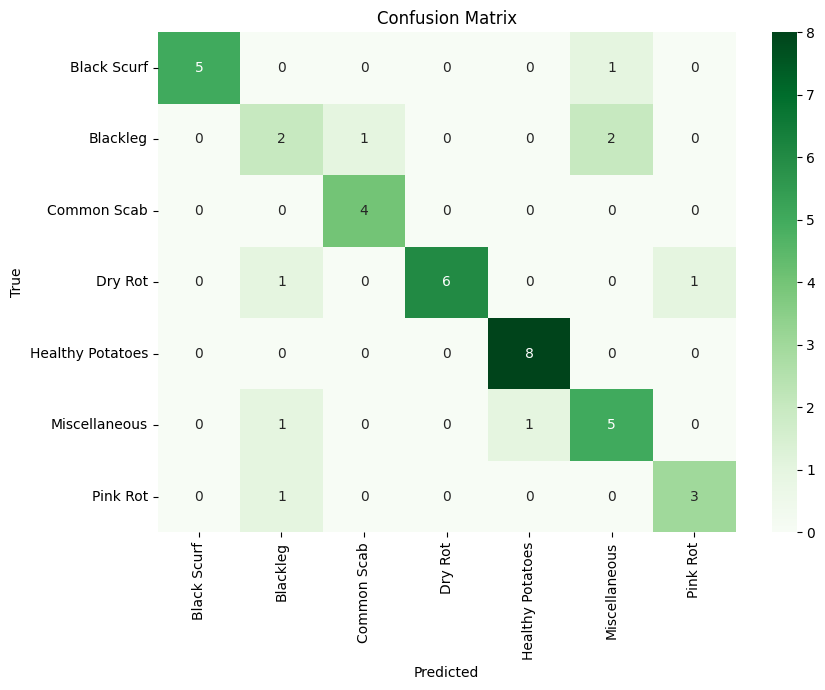

In [123]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
print(cm)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150)
plt.show()

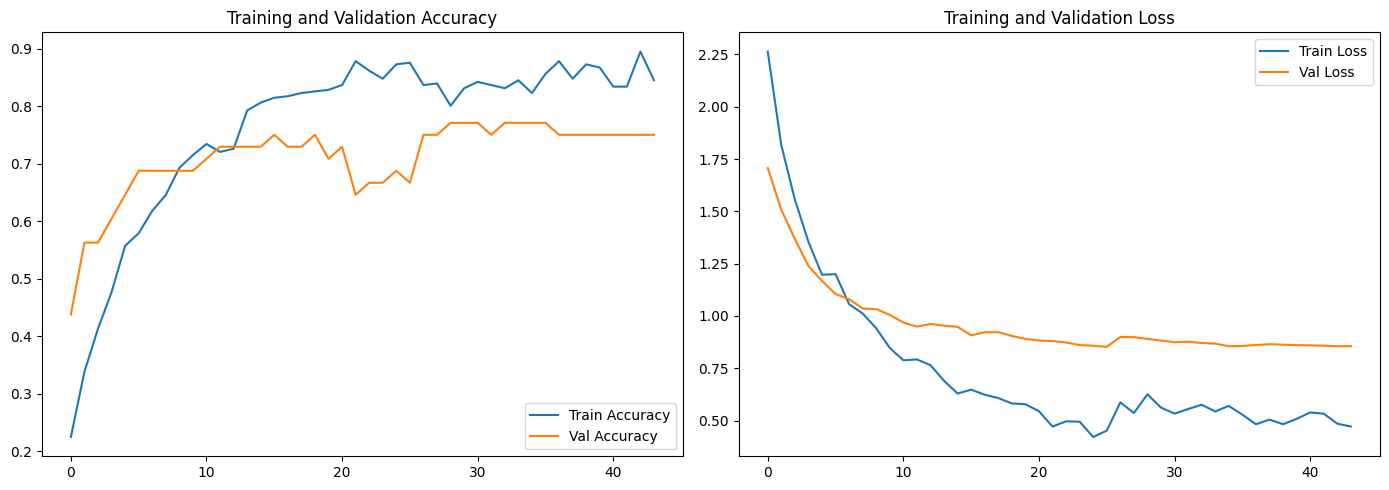

In [124]:

def plot_training_history(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')

    plt.tight_layout()
    plt.savefig('results/training_history.png', dpi=150)
    plt.show()

plot_training_history(h1, h2)

In [125]:
def predict_image(img_path, model, class_names):
    img       = tf.keras.utils.load_img(img_path, target_size=IMAGE_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)    
    pred      = model.predict(img_array, verbose=0)
    idx       = np.argmax(pred[0])
    print(f"Prediction : {class_names[idx]}")
    print(f"Confidence : {pred[0][idx]*100:.2f}%")
    return class_names[idx], pred[0][idx]

model = tf.keras.models.load_model('../saved_models/final_model.h5')
predict_image('testing_data/potato_black_scurf.png', model, class_names)

Prediction : Black Scurf
Confidence : 87.35%


('Black Scurf', 0.87349933)